# SelectKBest

# Imports

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/train.csv")

# Feature / Target Split (NO LEAKAGE)

In [ ]:
drop_cols = ['ID', 'result', 'age_desc']
X = df.drop(['Class/ASD'] + drop_cols, axis=1)
y = df['Class/ASD']

# Encode Categorical Features

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

# Scale Features (chi² REQUIREMENT)

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Train–Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SelectKBest

In [ ]:
selector = SelectKBest(score_func=chi2, k=10)
X_train_kbest = selector.fit_transform(X_train, y_train)
X_test_kbest = selector.transform(X_test)

# Selected Features (VERY IMPORTANT)

In [ ]:
selected_features = X_encoded.columns[selector.get_support()]
selected_features

Index(['A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score',
       'A9_Score', 'ethnicity_White-European', 'austim_yes',
       'contry_of_res_United States'],
      dtype='object')

# Train Classifier (Logistic Regression)

In [ ]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_kbest, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Evaluate

In [ ]:
y_pred = lr.predict(X_test_kbest)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.80625

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.80      0.87       128
           1       0.51      0.84      0.64        32

    accuracy                           0.81       160
   macro avg       0.73      0.82      0.75       160
weighted avg       0.86      0.81      0.82       160


Confusion Matrix:
 [[102  26]
 [  5  27]]


# Graphical Visualization

**Confusion Matrix Heatmap**

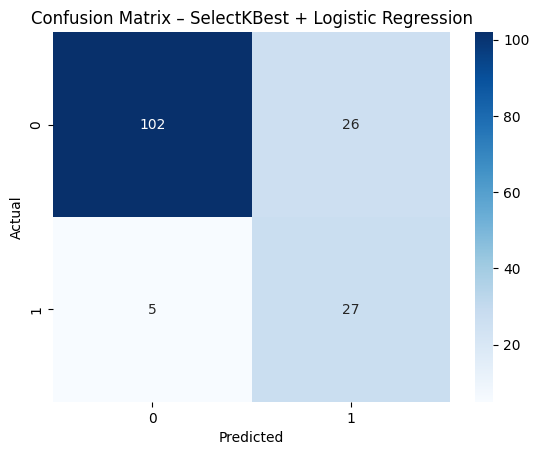

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SelectKBest + Logistic Regression")
plt.show()


# Feature Importance (Chi-Square Scores)

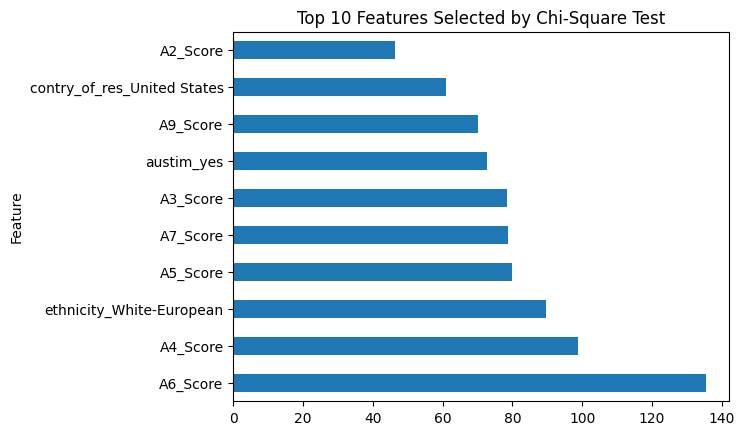

In [ ]:
scores = selector.scores_

feat_scores = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Score': scores
}).sort_values(by='Score', ascending=False).head(10)

feat_scores.plot(kind='barh', x='Feature', y='Score', legend=False)
plt.title("Top 10 Features Selected by Chi-Square Test")
plt.show()